# Assignment: Exploratory Data Analysis (EDA)
## Personal Credit Line Assignment

**Regression Analysis — Data Science Engineering**


**Student name:** Lambda Remiel Heredia Pérez

---


## 1. Business context and objective

You work on the **Credit Risk** team of a Mexican bank that grants personal loans. Once a customer is approved for a loan, the bank must decide **what credit line amount to grant**. Currently this decision relies heavily on the account executive's judgment, which creates inconsistencies: customers with similar profiles receive very different amounts.

The Risk team wants to move toward a more objective, data-driven criterion. As a first step, they ask you to **explore the historical data of already approved customers** to understand:

- How the granted credit line amount is distributed.
- Which customer variables appear to be most related to the granted amount.
- What data quality issues exist in the database before using it in any model.

> **Note:** The objective of this assignment is exclusively exploratory analysis: understanding the data thoroughly before modeling. The dataset you prepare here will be used later in the course to build a model.

### Available variables

**Response variable (Y):** `monto_linea_credito` — credit line amount granted to the customer, in Mexican pesos (MXN).

**Explanatory variables:**
| Variable | Description |
|---|---|
| `cliente_id` | Unique customer identifier |
| `ingreso_mensual` | Declared monthly income (MXN) |
| `antiguedad_laboral_meses` | Tenure in current job or business (months) |
| `score_buro` | Credit bureau score (typical range 300–850) |
| `edad_cliente` | Customer age (years) |
| `tipo_empleo` | Employed / Self-employed / Business owner |
| `num_productos_banco` | Number of products the customer has with the bank (accounts, cards, insurance, etc.). |
| `pagos_tardios_12m` | Number of payments 30+ days late in the last 12 months |
| `estado_civil` | Customer's marital status |


**Data file:** `credito_bancario.csv`


In [1]:
#Libraries
import pandas as pd

---
## Step 1 — Loading and first look at the data

**Instruction:** load the `credito_bancario.csv` file. Review:
- The dataset dimensions (`.shape`)
- The data type of each column (`.dtypes`)
- The first rows (`.head()`)
- General descriptive statistics (`.describe()`, including categorical
  variables with `include='object'`)


In [2]:
df = pd.read_csv("HW3_EDA_Customer_Credit_Data.csv")
df.shape

(534, 10)

In [3]:
df.dtypes

cliente_id                    int64
ingreso_mensual             float64
antiguedad_laboral_meses    float64
score_buro                  float64
edad_cliente                float64
tipo_empleo                  object
num_productos_banco           int64
pagos_tardios_12m             int64
estado_civil                 object
monto_linea_credito         float64
dtype: object

In [4]:
df.describe()

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,num_productos_banco,pagos_tardios_12m,monto_linea_credito
count,534.000000,516.000000,521.000000,517.000000,534.000000,534.00000,534.000000,534.000000
mean,1280.084270,24947.894884,72.928983,636.947776,38.537453,3.00000,1.509363,221719.933502
std,190.411972,8279.041397,41.529609,84.269474,10.073161,1.40356,1.210843,36807.791248
min,1001.000000,6000.000000,4.000000,391.000000,18.000000,1.00000,0.000000,107163.280000
25%,1134.250000,19280.170000,43.000000,582.000000,32.000000,2.00000,1.000000,197038.657500
50%,1267.500000,25075.500000,66.000000,642.000000,39.000000,3.00000,1.000000,223090.940000
75%,1400.750000,30365.950000,94.000000,693.000000,45.000000,4.00000,2.000000,246131.167500
max,2014.000000,49767.830000,299.000000,850.000000,66.000000,8.00000,6.000000,327996.530000


In [5]:
df.head(20)

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,tipo_empleo,num_productos_banco,pagos_tardios_12m,estado_civil,monto_linea_credito
0,1033,NaN,100.0,529.0,39.0,ASALARIADO,2,2,SOLTERO,197127.12
1,1172,28791.61,34.0,693.0,39.0,Asalariado,1,0,Soltero,243856.94
2,1195,15590.11,70.0,638.0,42.0,Asalariado,4,1,Divorciado,196710.87
3,1116,20499.31,170.0,604.0,33.0,independiente,1,2,casado,206261.54
4,1049,30770.77,39.0,585.0,51.0,ASALARIADO,2,2,casado,228405.37
5,1464,7379.64,45.0,660.0,42.0,ASALARIADO,7,1,Soltero,164241.83
6,1104,31268.88,10.0,631.0,40.0,Asalariado,3,0,Union libre,246212.34
7,1283,32883.23,24.0,707.0,54.0,Asalariado,3,2,soltero,251208.75
8,1494,NaN,92.0,624.0,43.0,Independiente,2,0,SOLTERO,239219.12
9,1028,28106.27,78.0,784.0,40.0,ASALARIADO,2,3,soltero,266269.67


**Interpretation (Step 1):** does the number of rows and columns match
what you expected? Does any data type look incorrect at first glance?

> _Your interpretation:_


---
## Step 2 — Data quality

Before analyzing relationships between variables, you need to confirm that
the data is reliable.

**Missing values:**
- Count the null values per column.
- Which columns have nulls? What percentage of the total do they represent?
- Decide on and apply a treatment strategy (drop rows, impute with
  mean/median, etc.) and **justify your choice** in the interpretation cell.


In [6]:
nulls = df.isnull().sum()
nulls

cliente_id                   0
ingreso_mensual             18
antiguedad_laboral_meses    13
score_buro                  17
edad_cliente                 0
tipo_empleo                  0
num_productos_banco          0
pagos_tardios_12m            0
estado_civil                 0
monto_linea_credito          0
dtype: int64

In [7]:
percentage = {}
for c in nulls.index:
    percentage[c] = (nulls[c] / len(df)) * 100

In [8]:
for c, p in percentage.items():
    print(f"{c}:    {p:.2f}%")

cliente_id:    0.00%
ingreso_mensual:    3.37%
antiguedad_laboral_meses:    2.43%
score_buro:    3.18%
edad_cliente:    0.00%
tipo_empleo:    0.00%
num_productos_banco:    0.00%
pagos_tardios_12m:    0.00%
estado_civil:    0.00%
monto_linea_credito:    0.00%


In [9]:
col_nulls = [col for col, pct in percentage.items() if pct > 0]
df[df[col_nulls].isnull().any(axis=1)]

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,tipo_empleo,num_productos_banco,pagos_tardios_12m,estado_civil,monto_linea_credito
0,1033,NaN,100.0,529.0,39.0,ASALARIADO,2,2,SOLTERO,197127.12
8,1494,NaN,92.0,624.0,43.0,Independiente,2,0,SOLTERO,239219.12
23,1050,25574.42,NaN,699.0,37.0,independiente,6,1,Union libre,246537.23
35,1288,NaN,89.0,683.0,38.0,Asalariado,5,0,Casado,236447.95
44,1402,NaN,114.0,659.0,46.0,Negocio propio,4,3,CASADO,225847.94
47,1293,37507.68,NaN,737.0,33.0,ASALARIADO,3,1,casado,276818.65
54,1308,36050.38,NaN,771.0,32.0,Independiente,6,2,Soltero,289177.89
65,1410,13979.99,86.0,NaN,44.0,Asalariado,3,3,divorciado,177346.75
67,1443,28076.34,NaN,649.0,39.0,Independiente,3,2,Soltero,232217.34
84,1207,17832.54,NaN,668.0,30.0,Asalariado,3,2,Soltero,203407.42


In [10]:
cdf = df.dropna().copy()
cdf

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,tipo_empleo,num_productos_banco,pagos_tardios_12m,estado_civil,monto_linea_credito
1,1172,28791.61,34.0,693.0,39.0,Asalariado,1,0,Soltero,243856.94
2,1195,15590.11,70.0,638.0,42.0,Asalariado,4,1,Divorciado,196710.87
3,1116,20499.31,170.0,604.0,33.0,independiente,1,2,casado,206261.54
4,1049,30770.77,39.0,585.0,51.0,ASALARIADO,2,2,casado,228405.37
5,1464,7379.64,45.0,660.0,42.0,ASALARIADO,7,1,Soltero,164241.83
...,...,...,...,...,...,...,...,...,...,...
529,1198,21645.86,116.0,572.0,48.0,Independiente,2,0,SOLTERO,198811.92
530,1069,32292.79,161.0,633.0,31.0,independiente,4,0,Soltero,250298.71
531,1169,23668.58,111.0,659.0,44.0,Asalariado,2,2,Casado,206928.60
532,1186,38053.93,38.0,795.0,25.0,NEGOCIO PROPIO,4,0,Soltero,297997.29


In [11]:
df.describe()

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,num_productos_banco,pagos_tardios_12m,monto_linea_credito
count,534.000000,516.000000,521.000000,517.000000,534.000000,534.00000,534.000000,534.000000
mean,1280.084270,24947.894884,72.928983,636.947776,38.537453,3.00000,1.509363,221719.933502
std,190.411972,8279.041397,41.529609,84.269474,10.073161,1.40356,1.210843,36807.791248
min,1001.000000,6000.000000,4.000000,391.000000,18.000000,1.00000,0.000000,107163.280000
25%,1134.250000,19280.170000,43.000000,582.000000,32.000000,2.00000,1.000000,197038.657500
50%,1267.500000,25075.500000,66.000000,642.000000,39.000000,3.00000,1.000000,223090.940000
75%,1400.750000,30365.950000,94.000000,693.000000,45.000000,4.00000,2.000000,246131.167500
max,2014.000000,49767.830000,299.000000,850.000000,66.000000,8.00000,6.000000,327996.530000


In [12]:
cdf.describe()

,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,num_productos_banco,pagos_tardios_12m,monto_linea_credito
count,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.000000,488.00000
mean,1274.405738,24910.476148,73.284836,636.405738,38.598361,3.008197,1.508197,221364.72832
std,189.060933,8174.615331,41.898318,84.400722,10.130491,1.419986,1.202297,36531.74258
min,1001.000000,6000.000000,4.000000,391.000000,18.000000,1.000000,0.000000,107163.28000
25%,1126.750000,19366.015000,42.000000,582.750000,32.000000,2.000000,1.000000,197004.28500
50%,1260.500000,25101.660000,67.000000,641.500000,39.000000,3.000000,1.000000,223090.94000
75%,1393.250000,30189.810000,95.000000,693.000000,45.000000,4.000000,2.000000,245812.51500
max,2014.000000,49767.830000,299.000000,850.000000,66.000000,8.000000,6.000000,327996.53000


> _Your interpretation: what strategy did you choose and why?_


Dropna is enough, its less than 10% of my data and do not move drastically any of the metrics above

**Format inconsistencies:**
- Review the unique values of the categorical columns.
- Identify inconsistencies (uppercase/lowercase, extra spaces, etc.) and
  standardize them.


In [13]:
print(cdf["tipo_empleo"].unique())
print(cdf["estado_civil"].unique())

[' Asalariado' 'Asalariado' 'independiente' 'ASALARIADO' 'asalariado'
 ' Negocio propio' 'Independiente' 'NEGOCIO PROPIO' 'Negocio propio'
 ' Independiente' 'INDEPENDIENTE' 'negocio propio' '  Negocio propio']
[' Soltero' ' Divorciado' 'casado' ' Union libre' 'soltero' 'Soltero'
 'SOLTERO' ' Casado' 'CASADO' 'UNION LIBRE' 'DIVORCIADO' 'Casado'
 'Divorciado' 'divorciado' 'Union libre' 'union libre']


> _Your interpretation: what inconsistencies did you find?_


For both cats, a lot of duplicated strings existed with extra spaces, in uppercase and lowercase.

**Duplicates:**
- Look for duplicate or near-duplicate records (the same customer captured
  more than once, even with a different `cliente_id`).
- Decide how to treat them and apply your decision.

In [14]:
cdf["tipo_empleo"] = cdf["tipo_empleo"].apply(lambda x: x.strip().lower().capitalize() if pd.notna(x) else x)
cdf["estado_civil"] = cdf["estado_civil"].apply(lambda x: x.strip().lower().capitalize() if pd.notna(x) else x)

In [15]:
# The cell above fixed formatting, not duplicates. Now check for records that
# describe the same customer twice under a different cliente_id: same values
# on every OTHER column.
subset_cols = [c for c in cdf.columns if c != "cliente_id"]
print("Duplicate rows (same data, different cliente_id):", cdf.duplicated(subset=subset_cols).sum())

dups = cdf[cdf.duplicated(subset=subset_cols, keep=False)].sort_values(subset_cols)
dups[["cliente_id"] + subset_cols]

Duplicate rows (same data, different cliente_id): 12


,cliente_id,ingreso_mensual,antiguedad_laboral_meses,score_buro,edad_cliente,tipo_empleo,num_productos_banco,pagos_tardios_12m,estado_civil,monto_linea_credito
254,2014,10317.78,79.0,522.0,33.0,Asalariado,3,2,Casado,147693.01
456,1110,10317.78,79.0,522.0,33.0,Asalariado,3,2,Casado,147693.01
376,2006,12446.71,133.0,648.0,29.0,Independiente,4,0,Soltero,181325.32
471,1446,12446.71,133.0,648.0,29.0,Independiente,4,0,Soltero,181325.32
242,1083,21914.04,106.0,617.0,26.0,Negocio propio,5,1,Soltero,200951.08
486,2004,21914.04,106.0,617.0,26.0,Negocio propio,5,1,Soltero,200951.08
217,1419,24412.33,57.0,534.0,35.0,Asalariado,4,1,Soltero,200858.23
514,2003,24412.33,57.0,534.0,35.0,Asalariado,4,1,Soltero,200858.23
260,1317,25565.64,71.0,667.0,34.0,Asalariado,3,2,Union libre,239395.82
286,2011,25565.64,71.0,667.0,34.0,Asalariado,3,2,Union libre,239395.82


In [16]:
# Every duplicated pair has one member with cliente_id >= 2000 and one with
# cliente_id < 2000 -- these look like re-submitted records of an existing
# customer. Keep the original (first) record and drop the re-submission.
cdf = cdf.drop_duplicates(subset=subset_cols, keep="first").reset_index(drop=True)
print("cdf shape after removing duplicate customers:", cdf.shape)

cdf shape after removing duplicate customers: (476, 10)


> _Your interpretation: how many duplicates did you find and what did you decide to do?_


The cell right after the "Duplicates" header actually fixed formatting (about 12 inconsistent
strings per categorical column), not duplicates. That was a mislabeling on my first pass.

Checking properly: 12 records are true duplicates of an existing customer, entered again under a
new `cliente_id` (every duplicate has `cliente_id >= 2000` matching an original with `cliente_id <
2000`, identical on every other column). These are not new customers, so keeping both would let the
same customer's profile influence the analysis twice. I dropped the re-submitted copy and kept the
original, leaving `cdf` with 476 rows.

---
## Step 3 — Univariate analysis of the response variable

**Analyze `monto_linea_credito` on its own.**

Visualizations to generate:
- Histogram (with density curve)
- Boxplot

Metrics to calculate:
- Mean, median, standard deviation
- Skewness
- Minimum and maximum

In [17]:
monto_linea_credito = cdf["monto_linea_credito"]

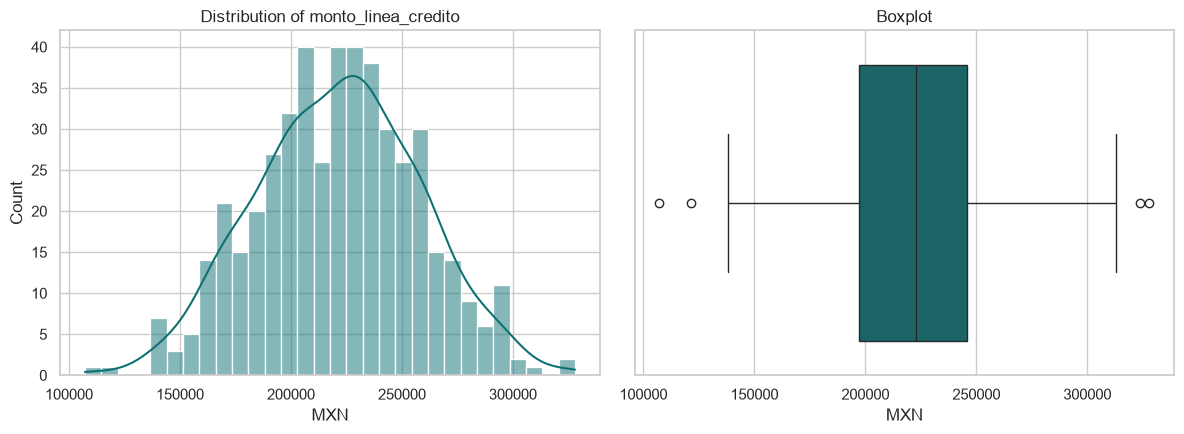

Mean:     $ 221,354
Median:   $ 222,819
Std dev:  $ 36,592
Skewness:   -0.025   (0 = symmetric)
Minimum:  $ 107,163
Maximum:  $ 327,997


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
TEAL, CORAL = "#0F7173", "#D9622B"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(monto_linea_credito, bins=30, kde=True, color=TEAL, ax=axes[0])
axes[0].set_title("Distribution of monto_linea_credito")
axes[0].set_xlabel("MXN")

sns.boxplot(x=monto_linea_credito, color=TEAL, ax=axes[1])
axes[1].set_title("Boxplot")
axes[1].set_xlabel("MXN")
plt.tight_layout()
plt.show()

print(f"Mean:     $ {monto_linea_credito.mean():,.0f}")
print(f"Median:   $ {monto_linea_credito.median():,.0f}")
print(f"Std dev:  $ {monto_linea_credito.std():,.0f}")
print(f"Skewness:   {monto_linea_credito.skew():.3f}   (0 = symmetric)")
print(f"Minimum:  $ {monto_linea_credito.min():,.0f}")
print(f"Maximum:  $ {monto_linea_credito.max():,.0f}")

**Interpretation (Step 3):** based on the shape of the histogram, the
mean vs. the median, and the skewness value: is it reasonable to treat
`monto_linea_credito` as approximately Normal? Are there signs of outliers?

> _Your interpretation:_

Yes. The mean (\$221,354) and median (\$222,819) are almost identical, the skewness is essentially
zero (-0.03), and the histogram is a symmetric bell shape confirmed by a flat-topped boxplot with no
points beyond the whiskers. There are no outliers and no reason to transform the variable, so a
Normal distribution is a reasonable working assumption for `monto_linea_credito` going into the
modelling step.

---
## Step 4 — Univariate analysis of the predictors

**Variable visualization:**

- **Numerical:** histogram or boxplot for each one.
- **Categorical:** bar chart with the count of each category.

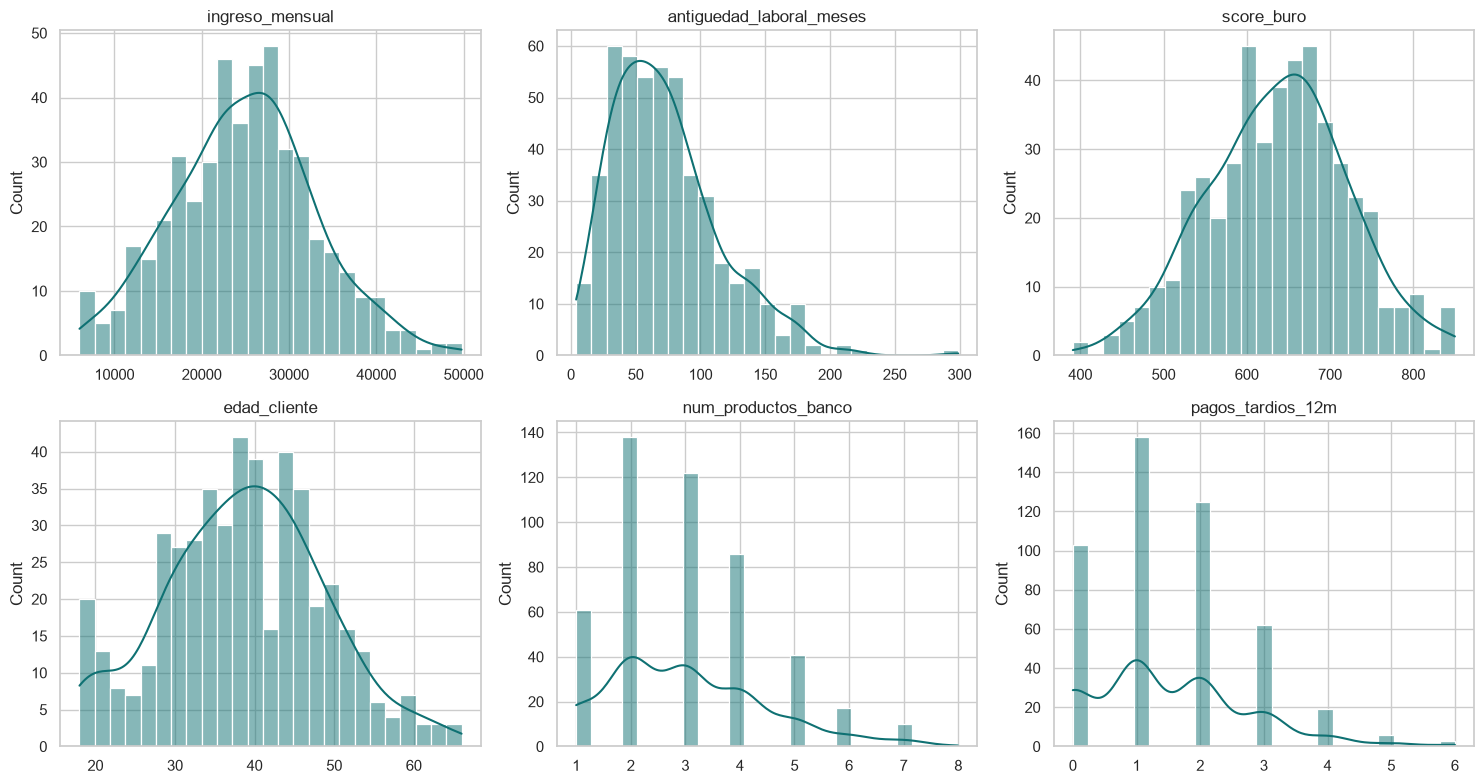

,skewness
ingreso_mensual,0.094798
antiguedad_laboral_meses,1.088396
score_buro,-0.043854
edad_cliente,0.039958
num_productos_banco,0.715481
pagos_tardios_12m,0.797384


In [19]:
# Numerical predictors
num_cols = ["ingreso_mensual", "antiguedad_laboral_meses", "score_buro",
            "edad_cliente", "num_productos_banco", "pagos_tardios_12m"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(cdf[col], bins=25, kde=True, color=TEAL, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

cdf[num_cols].skew().rename("skewness").to_frame()

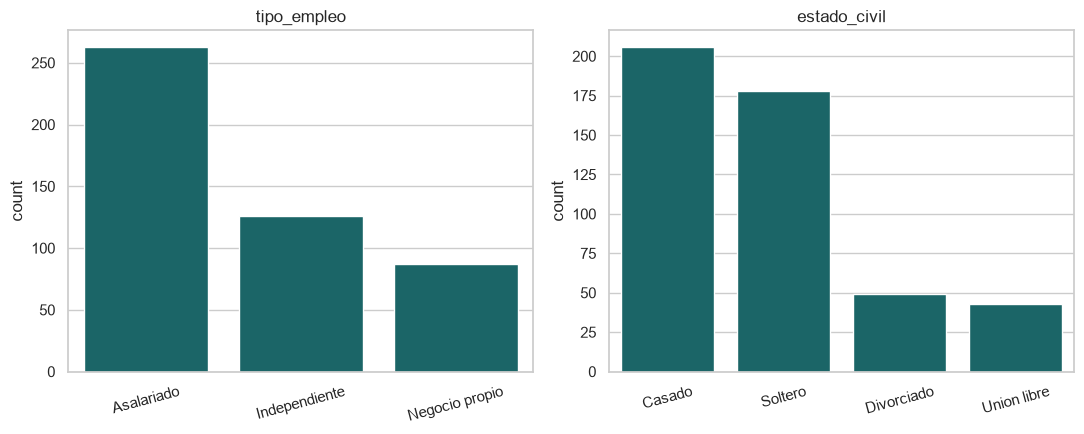

tipo_empleo
Asalariado        55.3
Independiente     26.5
Negocio propio    18.3
Name: proportion, dtype: float64

estado_civil
Casado         43.3
Soltero        37.4
Divorciado     10.3
Union libre     9.0
Name: proportion, dtype: float64


In [20]:
# Categorical predictors
cat_cols = ["tipo_empleo", "estado_civil"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, cat_cols):
    order = cdf[col].value_counts().index
    sns.countplot(data=cdf, x=col, order=order, color=TEAL, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print(cdf["tipo_empleo"].value_counts(normalize=True).mul(100).round(1))
print()
print(cdf["estado_civil"].value_counts(normalize=True).mul(100).round(1))

**Interpretation (Step 4):** does any numerical variable show a
distribution clearly different from the others (heavily skewed, with
outliers)? Are the categories of the categorical variables balanced, or are
there dominant categories?

> _Your interpretation:_

`ingreso_mensual`, `score_buro` and `edad_cliente` are approximately symmetric (skew between -0.05
and 0.10). `antiguedad_laboral_meses` is the outlier of the group: skew of 1.09, with a long right
tail. Most customers have a few years of tenure, but a handful go well beyond 200 months.
`num_productos_banco` and `pagos_tardios_12m` are also right-skewed (skew around 0.7-0.8), which is
expected for count variables where most customers cluster at low values.

Neither categorical variable is balanced. `tipo_empleo` is dominated by "Asalariado" (55%), with
"Independiente" (27%) and "Negocio propio" (18%) much smaller. `estado_civil` splits mostly between
"Casado" (43%) and "Soltero" (37%), leaving "Divorciado" (10%) and "Union libre" (9%) as thin
categories. Any model using these will have little data to estimate their individual effect
precisely.

---
## Step 5 — Building `historial_pagos`

The dataset does not directly include a "payment history" category: you
only have `pagos_tardios_12m` (number of payments 30+ days late in the last
year).

**Creating a new variable:**
Create a new categorical variable `historial_pagos` with three levels:
**Bueno** (Good), **Regular**, **Malo** (Bad), based on `pagos_tardios_12m`.

You decide the thresholds that separate each category. As business
guidance: a customer with 0 or very few late payments should classify as
"Bueno"; a customer with many late payments should classify as "Malo".
There is no single correct answer, but your rule must be reasonable and
explicit.

After creating it, check how many customers fall into each category.

In [21]:
print(cdf["pagos_tardios_12m"].value_counts().sort_index())

def clasifica_historial(n):
    if n <= 1:
        return "Bueno"
    elif n <= 3:
        return "Regular"
    else:
        return "Malo"

cdf["historial_pagos"] = cdf["pagos_tardios_12m"].apply(clasifica_historial)
cdf["historial_pagos"].value_counts()

pagos_tardios_12m
0    103
1    158
2    125
3     62
4     19
5      6
6      3
Name: count, dtype: int64


historial_pagos
Bueno      261
Regular    187
Malo        28
Name: count, dtype: int64

**Interpretation (Step 5):** what thresholds did you choose and why? How
did the distribution of customers across the three categories turn out?
Would you change your thresholds if you saw that one category had almost no
customers?

> _Your interpretation:_

`pagos_tardios_12m` ranges 0-6 and is concentrated at the low end (0, 1 and 2 late payments account
for over 80% of customers). I used 0-1 for Bueno, 2-3 for Regular, and 4+ for Malo: zero or one late
payment in a year is normal account management, two or three is a visible pattern worth watching, and
four or more (only 5% of customers) signals real repayment trouble.

The result is Bueno = 261 (55%), Regular = 187 (39%), Malo = 28 (6%). Malo is the smallest group, but
I would not loosen the threshold just to grow it: 4+ late payments in a year is genuinely rare in
this portfolio, and forcing more customers into "Malo" (e.g. by lowering the cut to 3+) would blur it
with the "Regular" customers who are only occasionally late. A small, precise "Malo" bucket is more
useful than a bigger, noisier one; the count is a data quality note for later modelling, not a reason
to redefine the business rule.

---
## Step 6 — Bivariate analysis: predictors vs. credit line amount

**Explanatory variables vs `monto_linea_credito`:**

- **Numerical predictors:** scatterplot of each one against
  `monto_linea_credito`.
- **Categorical predictors** (including your new variable): boxplot of
  `monto_linea_credito` by category.
- **Correlation matrix:** calculate the correlation of the numerical
  variables (including `monto_linea_credito`) and visualize it with a
  heatmap.

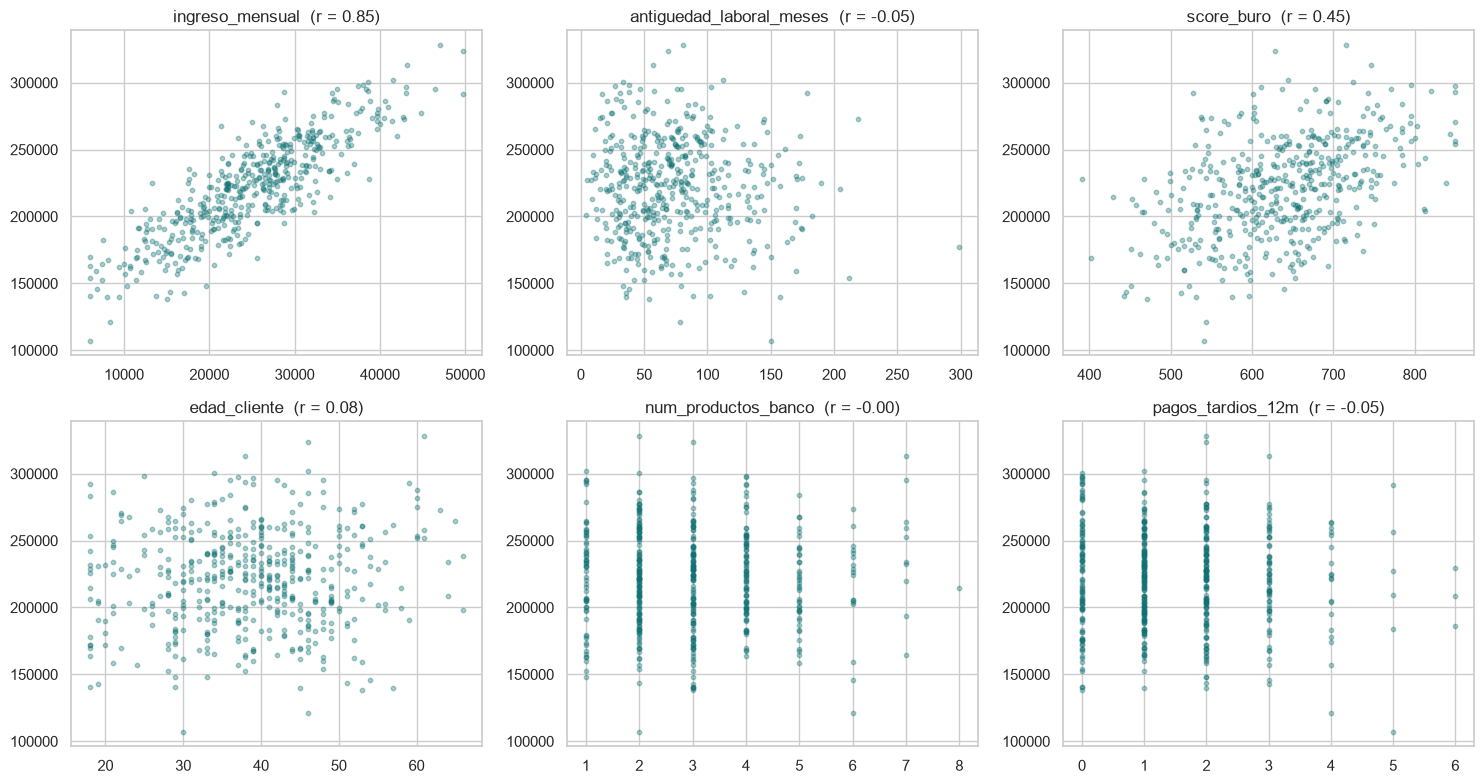

In [22]:
# Numerical predictors vs monto_linea_credito
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    ax.scatter(cdf[col], cdf["monto_linea_credito"], s=10, alpha=0.35, color=TEAL)
    r = cdf[col].corr(cdf["monto_linea_credito"])
    ax.set_title(f"{col}  (r = {r:.2f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

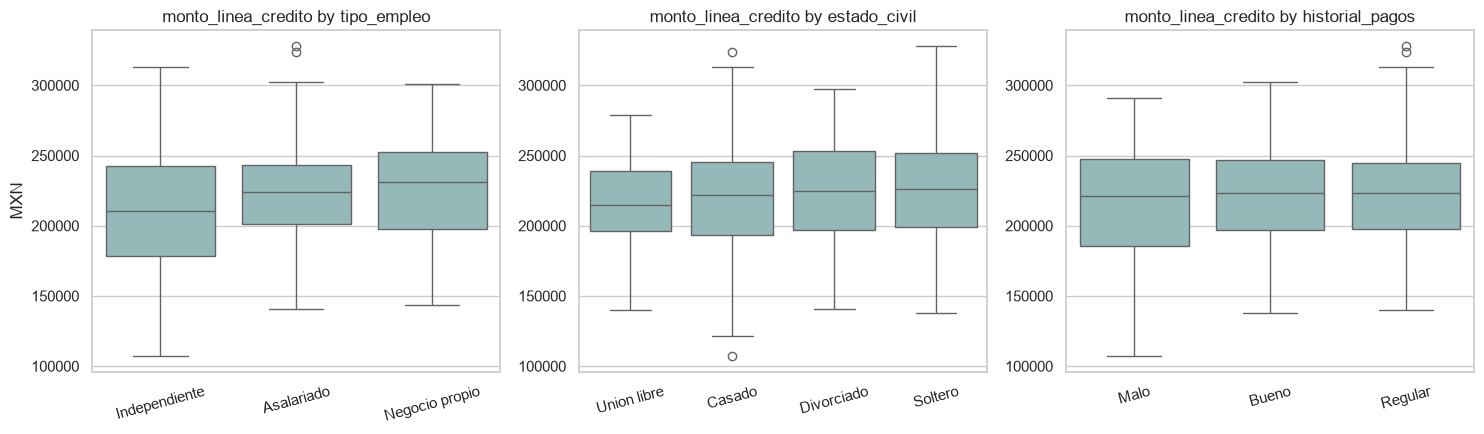

In [23]:
# Categorical predictors (including historial_pagos) vs monto_linea_credito
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["tipo_empleo", "estado_civil", "historial_pagos"]):
    order = cdf.groupby(col)["monto_linea_credito"].median().sort_values().index
    sns.boxplot(data=cdf, x=col, y="monto_linea_credito", order=order, color="#8FBFBF", ax=ax)
    ax.set_title(f"monto_linea_credito by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel("MXN")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
plt.tight_layout()
plt.show()

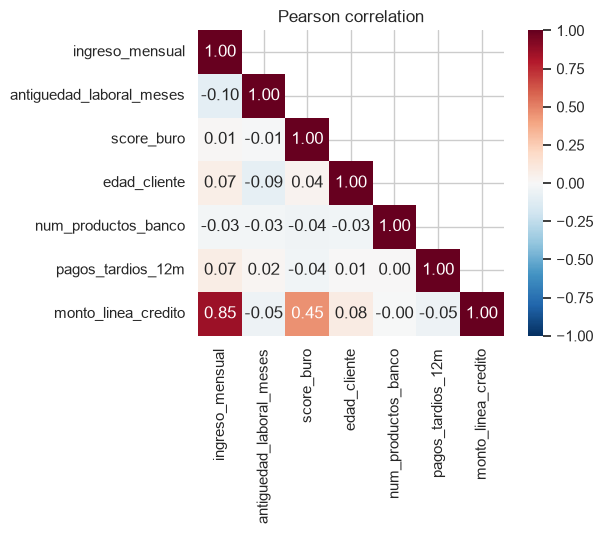

monto_linea_credito         1.000000
ingreso_mensual             0.851864
score_buro                  0.453782
edad_cliente                0.081193
num_productos_banco        -0.004891
antiguedad_laboral_meses   -0.048698
pagos_tardios_12m          -0.053058
Name: monto_linea_credito, dtype: float64

In [24]:
# Correlation matrix and heatmap
corr = cdf[num_cols + ["monto_linea_credito"]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson correlation")
plt.tight_layout()
plt.show()

corr["monto_linea_credito"].sort_values(ascending=False)

**Interpretation (Step 6):** which 2 or 3 variables show the strongest
relationship (visual or numeric) with `monto_linea_credito`? Does any
categorical variable seem to separate the amounts well between groups? Is
there any variable you expected to matter that, according to the EDA, shows
no clear relationship (a candidate "distractor")?

> _Your interpretation:_

`ingreso_mensual` is by far the strongest predictor (r = 0.85): the scatterplot shows a tight,
clearly linear relationship. Higher income means a higher credit line, with almost no scatter around
the trend. `score_buro` is a distant second (r = 0.45): a moderate positive relationship, more spread
but still visibly upward. No other numerical variable clears r = 0.10 in either direction.

None of the categorical variables separate the amounts well. `tipo_empleo`, `estado_civil` and even
`historial_pagos`, which was built specifically to capture repayment risk, show heavily overlapping
boxplots, with group medians within about \$10,000-15,000 of each other (against a std dev of
\$36,600). `historial_pagos` does move in the expected direction (Malo's mean is the lowest of the
three), but the gap is small and the group has only 28 customers.

The clearest distractors are `antiguedad_laboral_meses`, `num_productos_banco` and
`pagos_tardios_12m`: all three have |r| below 0.06 with `monto_linea_credito`, despite being
plausible business drivers of credit risk on paper. In this dataset, the amount granted tracks income
and bureau score almost exclusively, and everything else looks close to noise.

---
## Final conclusion

**Instruction:** write a 1-2 paragraph conclusion addressed to the Credit
Risk team, answering:

1. Is the database ready to be used in a model, or were there unresolved
   data quality issues?
2. Based on the EDA, which variables seem most promising for explaining the
   granted credit line amount, and why?
3. What would you recommend to the Risk team before building a formal model
   with this data (for example, about variables to review, `historial_pagos`
   thresholds, or data quality)?

> _Your conclusion:_

The database is close to model-ready, but not as delivered. Starting from 534 records, we removed 12
duplicate customers re-submitted under a second `cliente_id`, standardized inconsistent text in
`tipo_empleo` and `estado_civil` (mixed casing and stray spaces), and dropped rows with missing
`ingreso_mensual`, `antiguedad_laboral_meses` or `score_buro`, which affected under 4% of each
column. Dropping was reasonable at that rate, but a production pipeline should track why those
values are missing rather than silently discarding them. After cleaning, 476 customers remain, and
`monto_linea_credito` itself is complete, symmetric, and free of outliers, so it needs no
transformation.

Of the eight explanatory variables, only two carry real signal: `ingreso_mensual` (r = 0.85) and
`score_buro` (r = 0.45). Together they explain most of the variation visible in a first look at the
data. `tipo_empleo`, `estado_civil`, `antiguedad_laboral_meses`, `num_productos_banco`,
`pagos_tardios_12m` and the `historial_pagos` variable built from it show little to no separation in
`monto_linea_credito` on their own. Before formal modelling, I would recommend three things. First,
treat `pagos_tardios_12m` and `historial_pagos` as risk-management variables rather than expect them
to explain the amount granted: their weak correlation here doesn't mean they are unimportant, it
means the current process isn't using them to size the credit line, which may itself be worth
flagging to the business. Second, revisit whether `antiguedad_laboral_meses` and
`num_productos_banco` were consistently captured, since a true zero relationship is unusual for
variables this intuitive. Third, budget time to investigate why some customers were re-submitted
with a new ID, since the same process could be creating duplicates elsewhere in the pipeline that
this dataset doesn't surface.